1 - Plot the Repos by age group and add the age group next to the main speadsheet

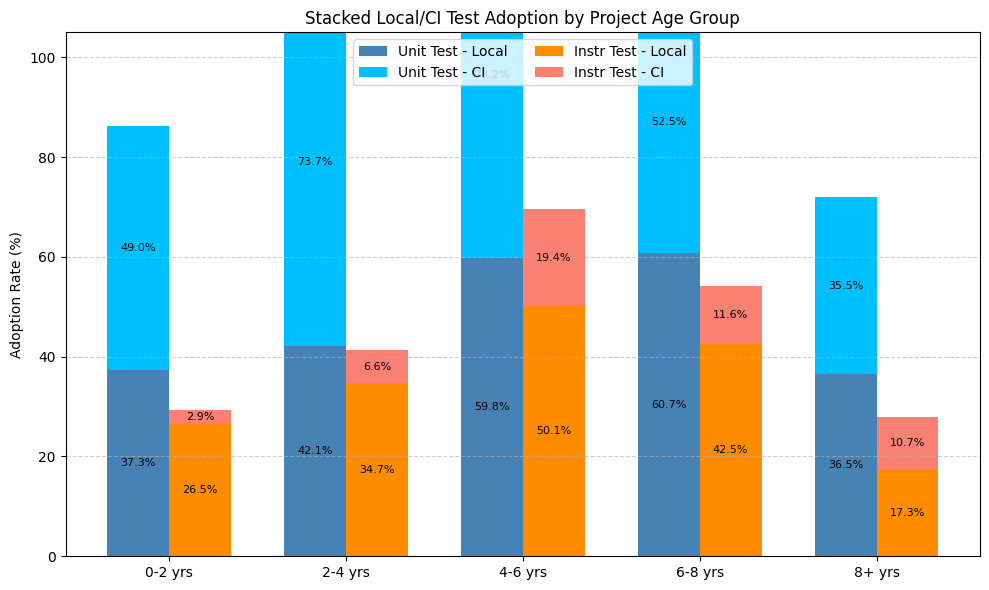

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load the dataset ===
file_path = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
df = pd.read_csv(file_path)

# === Convert all relevant columns to boolean ===
for col in [
    "has_local_unit_test", "Unit_Test_CI",
    "has_local_instrumentation_test", "Instrumentation_Test_CI",
    "Instrumentation_Test(Local or CI)", "Unit_Test(Local or CI)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === GLOBAL STACKED BAR PLOTTING FUNCTION ===
def plot_stacked_bar(df, category, title):
    x = np.arange(len(df[category]))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))

    unit_local = ax.bar(x - width/2, df["Unit_Local"], width, label='Unit Test - Local', color='steelblue')
    unit_ci = ax.bar(x - width/2, df["Unit_CI"], width, bottom=df["Unit_Local"], label='Unit Test - CI', color='deepskyblue')
    instr_local = ax.bar(x + width/2, df["Instr_Local"], width, label='Instr Test - Local', color='darkorange')
    instr_ci = ax.bar(x + width/2, df["Instr_CI"], width, bottom=df["Instr_Local"], label='Instr Test - CI', color='salmon')

    def label_bars(bottoms, heights, xpos):
        for bottom, height, x_pos in zip(bottoms, heights, xpos):
            if height > 0.5:
                ax.text(x_pos, bottom + height / 2, f"{height:.1f}%", ha='center', va='center', fontsize=8)

    label_bars(np.zeros_like(x), df["Unit_Local"], x - width/2)
    label_bars(df["Unit_Local"], df["Unit_CI"], x - width/2)
    label_bars(np.zeros_like(x), df["Instr_Local"], x + width/2)
    label_bars(df["Instr_Local"], df["Instr_CI"], x + width/2)

    ax.set_ylabel("Adoption Rate (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df[category])
    ax.set_ylim(0, 105)
    ax.legend(loc='upper center', ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# === Analyze Test Adoption by Importance Quantile ===
if "importance_quantile" in df.columns:
    df_nonzero = df.dropna(subset=["importance_quantile"]).copy()
    df_nonzero["importance_quantile"] = df_nonzero["importance_quantile"].astype(str)

    grouped_importance = df_nonzero.groupby("importance_quantile", observed=False)[
        ["has_local_unit_test", "Unit_Test_CI", "has_local_instrumentation_test", "Instrumentation_Test_CI"]
    ].mean() * 100

    stacked_imp_df = pd.DataFrame({
        "importance_quantile": grouped_importance.index,
        "Unit_Local": grouped_importance["has_local_unit_test"],
        "Unit_CI": grouped_importance["Unit_Test_CI"],
        "Instr_Local": grouped_importance["has_local_instrumentation_test"],
        "Instr_CI": grouped_importance["Instrumentation_Test_CI"]
    })

    plot_stacked_bar(stacked_imp_df, "importance_quantile", "Stacked Local/CI Test Adoption by Importance Quantile")

# === Analyze Test Adoption by Project Age Group and Save Age Group ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp("2025-06-11") - df["created_at"]).dt.days / 365.25
df["age_group"] = pd.cut(
    df["project_age_years"],
    bins=[0, 2, 4, 6, 8, 20],
    labels=["0-2 yrs", "2-4 yrs", "4-6 yrs", "6-8 yrs", "8+ yrs"]
)

df_age = df.dropna(subset=["age_group"])

grouped = df_age.groupby("age_group", observed=False)[
    ["has_local_unit_test", "Unit_Test_CI", "has_local_instrumentation_test", "Instrumentation_Test_CI"]
].mean() * 100

stacked_df = pd.DataFrame({
    "age_group": grouped.index.astype(str),
    "Unit_Local": grouped["has_local_unit_test"],
    "Unit_CI": grouped["Unit_Test_CI"],
    "Instr_Local": grouped["has_local_instrumentation_test"],
    "Instr_CI": grouped["Instrumentation_Test_CI"]
})

plot_stacked_bar(stacked_df, "age_group", "Stacked Local/CI Test Adoption by Project Age Group")

# === Save updated CSV with age group column ===
df.to_csv(file_path, index=False)


2 - Plot the Repos by age group and add the age group next to the main speadsheet Only for Isntru Test

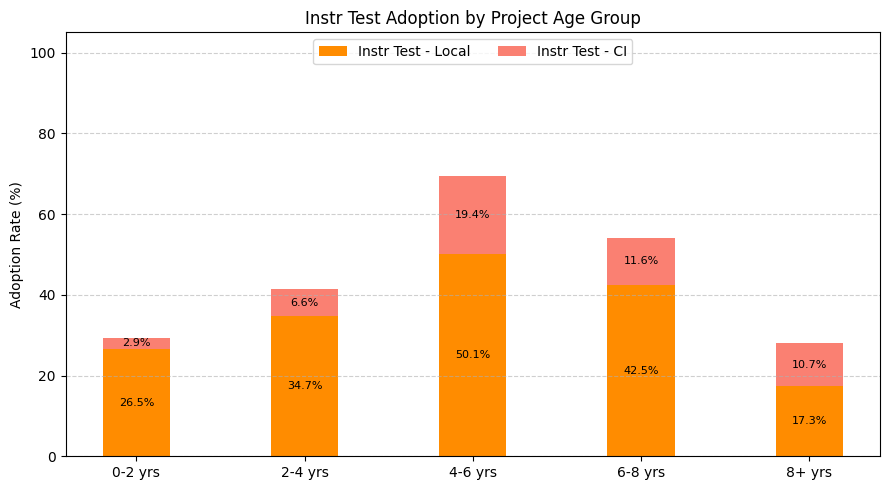

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load the dataset ===
file_path = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "has_local_unit_test", "Unit_Test_CI",
    "has_local_instrumentation_test", "Instrumentation_Test_CI",
    "Instrumentation_Test(Local or CI)", "Unit_Test(Local or CI)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === MODIFIED PLOT: Instrumentation Only ===
def plot_stacked_bar(df, category, title):
    x = np.arange(len(df[category]))
    width = 0.4
    fig, ax = plt.subplots(figsize=(9, 5))

    instr_local = ax.bar(x, df["Instr_Local"], width, label='Instr Test - Local', color='darkorange')
    instr_ci = ax.bar(x, df["Instr_CI"], width, bottom=df["Instr_Local"], label='Instr Test - CI', color='salmon')

    def label_bars(bottoms, heights, xpos):
        for bottom, height, x_pos in zip(bottoms, heights, xpos):
            if height > 0.5:
                ax.text(x_pos, bottom + height / 2, f"{height:.1f}%", ha='center', va='center', fontsize=8)

    label_bars(np.zeros_like(x), df["Instr_Local"], x)
    label_bars(df["Instr_Local"], df["Instr_CI"], x)

    ax.set_ylabel("Adoption Rate (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df[category])
    ax.set_ylim(0, 105)
    ax.legend(loc='upper center', ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# === Analyze by Importance Quantile (Instr Only) ===
if "importance_quantile" in df.columns:
    df_nonzero = df.dropna(subset=["importance_quantile"]).copy()
    df_nonzero["importance_quantile"] = df_nonzero["importance_quantile"].astype(str)

    grouped_importance = df_nonzero.groupby("importance_quantile", observed=False)[
        ["has_local_instrumentation_test", "Instrumentation_Test_CI"]
    ].mean() * 100

    stacked_imp_df = pd.DataFrame({
        "importance_quantile": grouped_importance.index,
        "Instr_Local": grouped_importance["has_local_instrumentation_test"],
        "Instr_CI": grouped_importance["Instrumentation_Test_CI"]
    })

    plot_stacked_bar(stacked_imp_df, "importance_quantile", "Instr Test Adoption by Importance Quantile")

# === Analyze by Age Group (Instr Only) ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp("2025-06-11") - df["created_at"]).dt.days / 365.25
df["age_group"] = pd.cut(
    df["project_age_years"],
    bins=[0, 2, 4, 6, 8, 20],
    labels=["0-2 yrs", "2-4 yrs", "4-6 yrs", "6-8 yrs", "8+ yrs"]
)

df_age = df.dropna(subset=["age_group"])

grouped = df_age.groupby("age_group", observed=False)[
    ["has_local_instrumentation_test", "Instrumentation_Test_CI"]
].mean() * 100

stacked_df = pd.DataFrame({
    "age_group": grouped.index.astype(str),
    "Instr_Local": grouped["has_local_instrumentation_test"],
    "Instr_CI": grouped["Instrumentation_Test_CI"]
})

plot_stacked_bar(stacked_df, "age_group", "Instr Test Adoption by Project Age Group")

# === Save updated CSV with age group ===
df.to_csv(file_path, index=False)


Grouping the repos to these tiers: 

    Tier 0 – Fully Or Partially Automated: Has CI instrumentation tests
    Tier 1 – Fully Ready: Has local instrumentation tests, Has not CI instrumentation test
    Tier 2 – Partially Ready: Has unit tests only (either local or CI), but no instrumentation tests(Local or CI).
    Tier 3 – Not Ready: Has neither unit nor instrumentation tests.
Saves the Tier of each Repo in the main spreadsheet



✅ Tiered CSV saved to: F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv


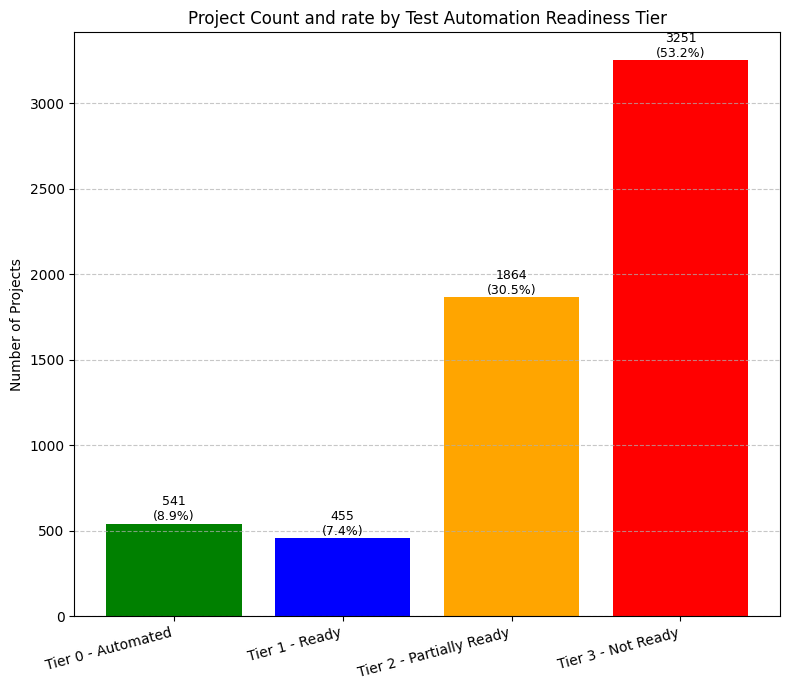

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === CONFIGURATION ===
input_csv = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
output_csv = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"

# === LOAD DATA ===
df = pd.read_csv(input_csv)

# === ENSURE BOOLEAN COLUMNS ===
df["Instrumentation_Test_CI"] = df["Instrumentation_Test_CI"].astype(str).str.lower() == "true"
df["has_local_instrumentation_test"] = df["has_local_instrumentation_test"].astype(str).str.lower() == "true"
df["Unit_Test_CI"] = df["Unit_Test_CI"].astype(str).str.lower() == "true"
df["has_local_unit_test"] = df["has_local_unit_test"].astype(str).str.lower() == "true"

# === DEFINE TIER CLASSIFICATION FUNCTION ===
def classify_tier(row):
    has_ci_instr = row["Instrumentation_Test_CI"]
    has_local_instr = row["has_local_instrumentation_test"]
    has_unit_test = row["Unit_Test_CI"] or row["has_local_unit_test"]

    if has_ci_instr:
        return "Tier 0 - Automated"
    elif has_local_instr and not has_ci_instr:
        return "Tier 1 - Ready"
    elif has_unit_test and not has_local_instr and not has_ci_instr:
        return "Tier 2 - Partially Ready"
    else:
        return "Tier 3 - Not Ready"

# === APPLY TIER CLASSIFICATION ===
df["Readiness_Tier"] = df.apply(classify_tier, axis=1)

# === SAVE OUTPUT ===
df.to_csv(output_csv, index=False)
print(f"✅ Tiered CSV saved to: {output_csv}")

# === OPTIONAL: PLOT BAR CHART OF TIERS ===
tier_order = [
    "Tier 0 - Automated",
    "Tier 1 - Ready",
    "Tier 2 - Partially Ready",
    "Tier 3 - Not Ready"
]
tier_counts = df["Readiness_Tier"].value_counts().reindex(tier_order, fill_value=0)
total = tier_counts.sum()
tier_percentages = (tier_counts / total * 100).round(1)

plt.figure(figsize=(8, 7))
bars = plt.bar(tier_counts.index, tier_counts.values, color=["green", "blue", "orange", "red"])
plt.title("Project Count and rate by Test Automation Readiness Tier")
plt.ylabel("Number of Projects")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for bar, pct in zip(bars, tier_percentages):
    height = bar.get_height()
    label = f"{int(height)}\n({pct:.1f}%)"
    plt.text(bar.get_x() + bar.get_width() / 2, height + 2, label,
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Plot the CI Platfomr's with Instrumentation testing Frequency

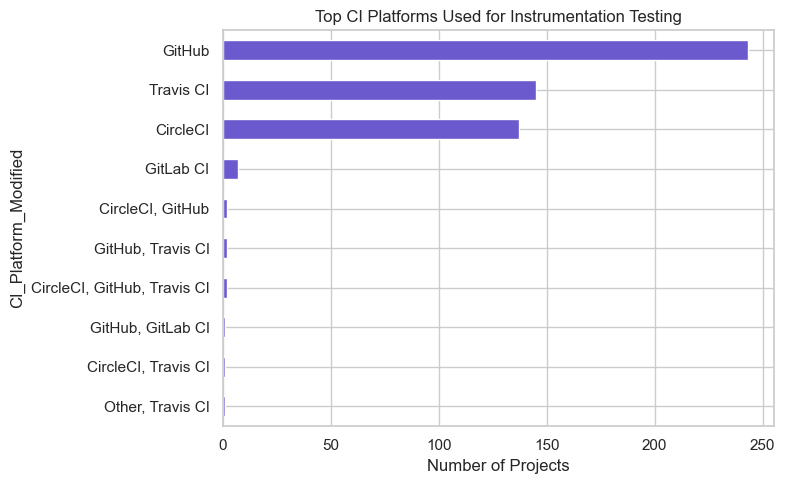

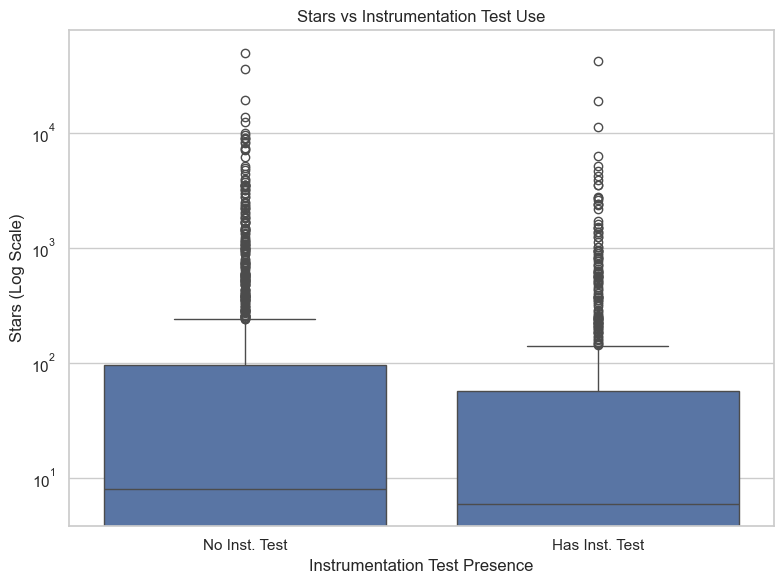

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv")

# Clean values
df['CI_Platform_Modified'] = df['CI_Platform_Modified'].fillna("None")
df['Test_Type_Group'] = df['Test_Type_Group'].fillna("None")
df['Instrumentation_Test(Local or CI)'] = df['Instrumentation_Test(Local or CI)'].astype(str)

sns.set(style="whitegrid")


# 2. CI Platforms used in Instrumentation Testing
ci_platform_counts = df[df['Instrumentation_Test_CI'] == True]['CI_Platform_Modified'].value_counts().head(10)
plt.figure(figsize=(8, 5))
ci_platform_counts.plot(kind='barh', color='slateblue')
plt.title("Top CI Platforms Used for Instrumentation Testing")
plt.xlabel("Number of Projects")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



# 4. Stars vs. Instrumentation Test Use (Boxplot)
df['Instrumentation Test Presence'] = df['Instrumentation_Test(Local or CI)'].map({'True': 'Has Inst. Test', 'False': 'No Inst. Test'})
df_plot = df[['Instrumentation Test Presence', 'stars']].dropna()
df_plot['stars'] = pd.to_numeric(df_plot['stars'], errors='coerce')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Instrumentation Test Presence', y='stars', data=df_plot)
plt.yscale('log')
plt.title("Stars vs Instrumentation Test Use")
plt.ylabel("Stars (Log Scale)")
plt.xlabel("Instrumentation Test Presence")
plt.tight_layout()
plt.show()




C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


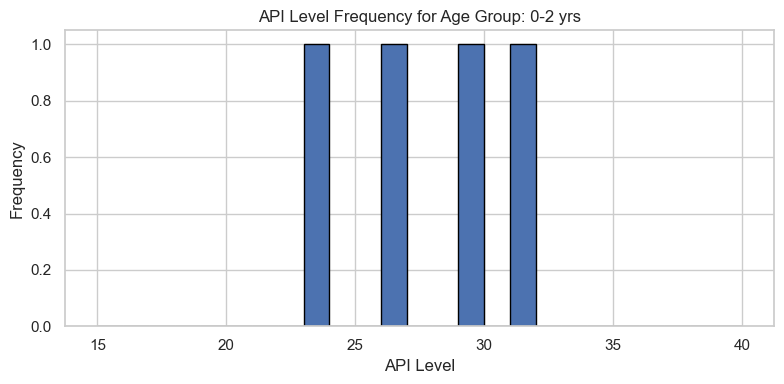

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


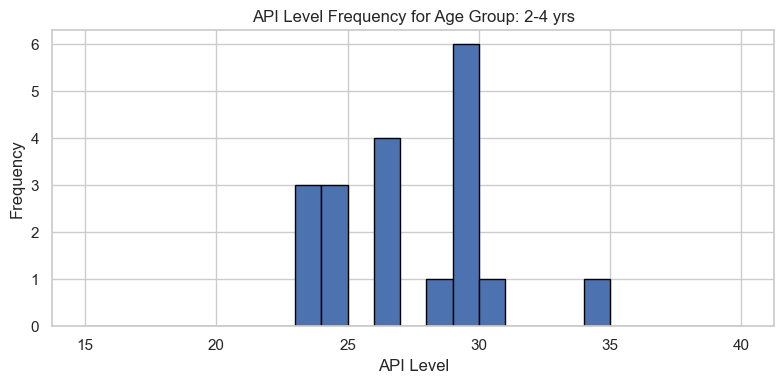

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


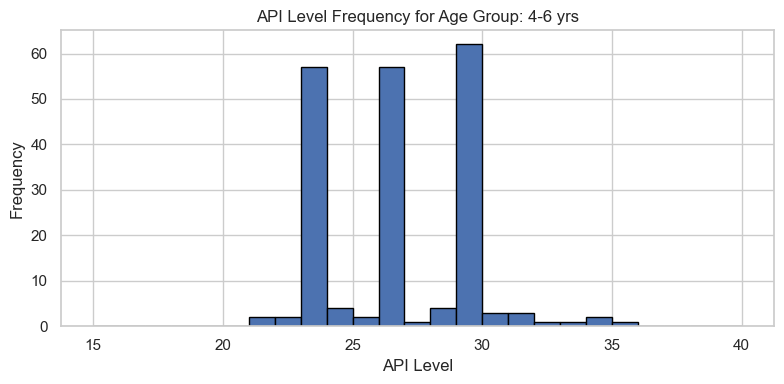

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


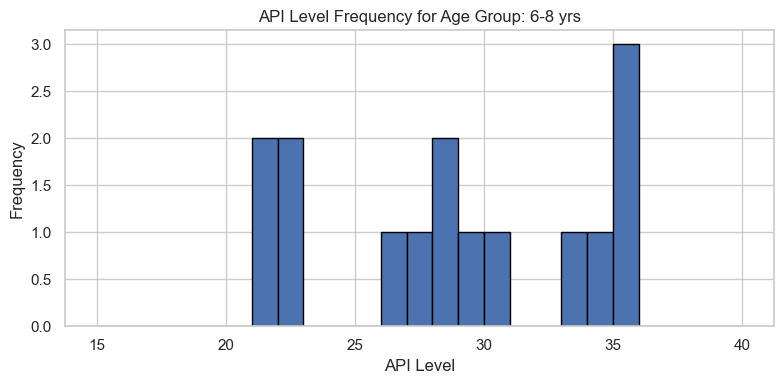

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


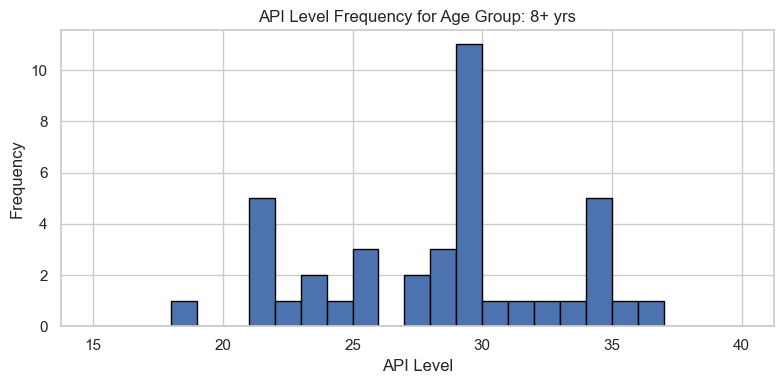

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
# Adjust paths if needed
REPO_METRICS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
API_DETAILS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.2-Project_List_API_Details_3rdAttempt_ShallowC.csv"

# === Load CSV files ===
repo_metrics = pd.read_csv(REPO_METRICS_CSV)
api_details = pd.read_csv(API_DETAILS_CSV)

# === Merge to attach 'age_group' to each API level ===
merged_df = pd.merge(
    api_details,
    repo_metrics[['full_name', 'age_group']],
    on='full_name',
    how='left'
)

# === Plot: Histogram for each age group ===
# Get unique age groups (drop NaN)
age_groups = merged_df['age_group'].dropna().unique()

# Loop over each age group and plot histogram
for age_group in sorted(age_groups):
    group_df = merged_df[merged_df['age_group'] == age_group]
    plt.figure(figsize=(8, 4))
    # Ensure API levels are integers
    group_df['api_level'] = group_df['api_level'].astype(int)
    # Plot histogram with bin range covering typical Android API levels
    group_df['api_level'].hist(
        bins=range(15, 41),
        edgecolor='black'
    )
    plt.title(f"API Level Frequency for Age Group: {age_group}")
    plt.xlabel("API Level")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


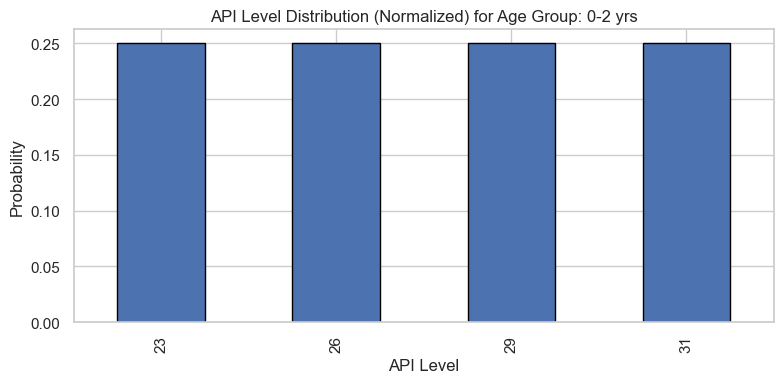

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


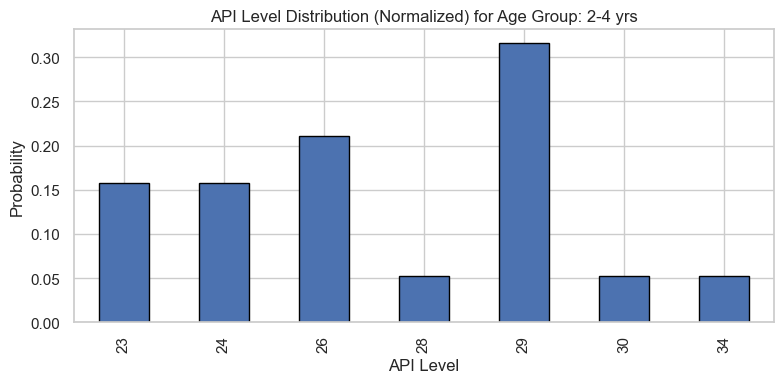

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


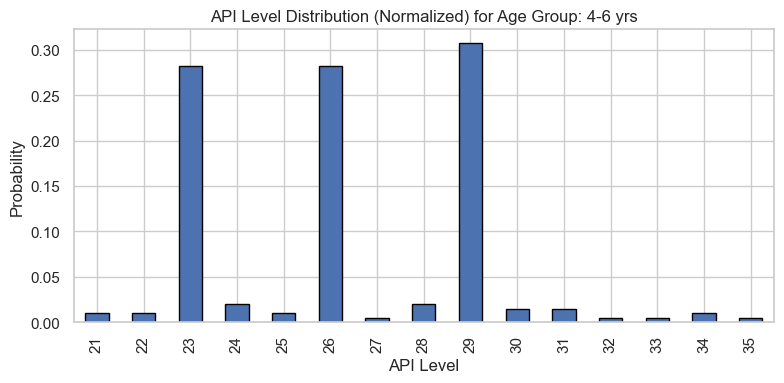

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


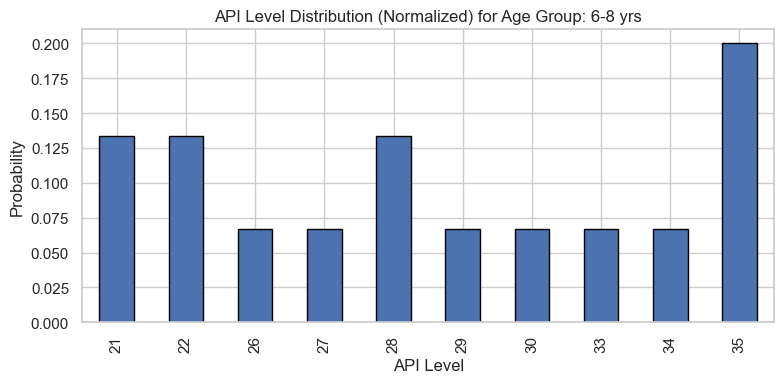

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


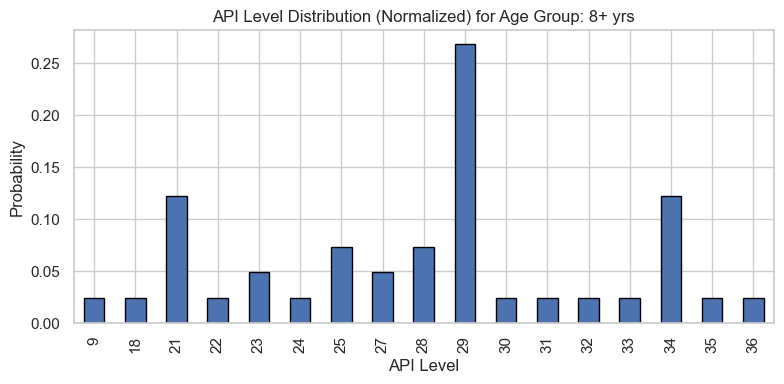

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
REPO_METRICS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
API_DETAILS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.2-Project_List_API_Details_3rdAttempt_ShallowC.csv"

# === Load CSV files ===
repo_metrics = pd.read_csv(REPO_METRICS_CSV)
api_details = pd.read_csv(API_DETAILS_CSV)

# === Merge ===
merged_df = pd.merge(
    api_details,
    repo_metrics[['full_name', 'age_group']],
    on='full_name',
    how='left'
)

# === Plot: API level distribution (normalized) for each age group ===
age_groups = merged_df['age_group'].dropna().unique()

for age_group in sorted(age_groups):
    group_df = merged_df[merged_df['age_group'] == age_group]
    group_df['api_level'] = group_df['api_level'].astype(int)

    # Count occurrences
    counts = group_df['api_level'].value_counts().sort_index()
    total = counts.sum()

    # Normalize to get distribution
    probs = counts / total

    # Plot
    plt.figure(figsize=(8, 4))
    probs.plot(kind='bar', edgecolor='black')
    plt.title(f"API Level Distribution (Normalized) for Age Group: {age_group}")
    plt.xlabel("API Level")
    plt.ylabel("Probability")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
